# **Point Net - Classification**

In [1]:
import os
import re
from glob import glob
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchmetrics
from torchmetrics.classification import MulticlassMatthewsCorrCoef
import open3d as o3

from open3d.web_visualizer import draw # for non Colab
import os, os.path as osp

import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
[Open3D INFO] Resetting default logger to print to terminal.


In [2]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DEVICE

'cuda'

## Now: feature extraction of the foils

In [3]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
import warnings
from models.point_net.point_net import PointNetClassHead
from shapely.geometry import Polygon
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import LinearSegmentedColormap, ListedColormap, BoundaryNorm

# from analyze_pointnet_backbone import analyze_pointnet_backbone
from models.point_net.analyze_pointnet_backbone import analyze_pointnet_backbone2
plots = True
  

### cls_model_35

[cls_model_35] Model loaded from: models/point_net/trained_models/cls_focal_clr/cls_model_35.pth
[cls_model_35] Collected features: X=(1000, 1024), labels=(1000,)
[cls_model_35] Saved extracted features to:
  - c:\Users\romai\OneDrive\Bureau\EPFL\MA3\Project\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE\extracted_features\cls_model_35_Default\cls_model_35_Default_features.csv
  - c:\Users\romai\OneDrive\Bureau\EPFL\MA3\Project\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE\extracted_features\cls_model_35_Default\cls_model_35_Default_features.parquet
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1000 samples in 0.000s...
[t-SNE] Computed neighbors for 1000 samples in 0.013s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1000
[t-SNE] Mean sigma: 0.000118
[t-SNE] KL divergence after 250 iterations with early exaggeration: 51.345242
[t-SNE] KL divergence after 1000 iterations: 0.404796
[cls_mo

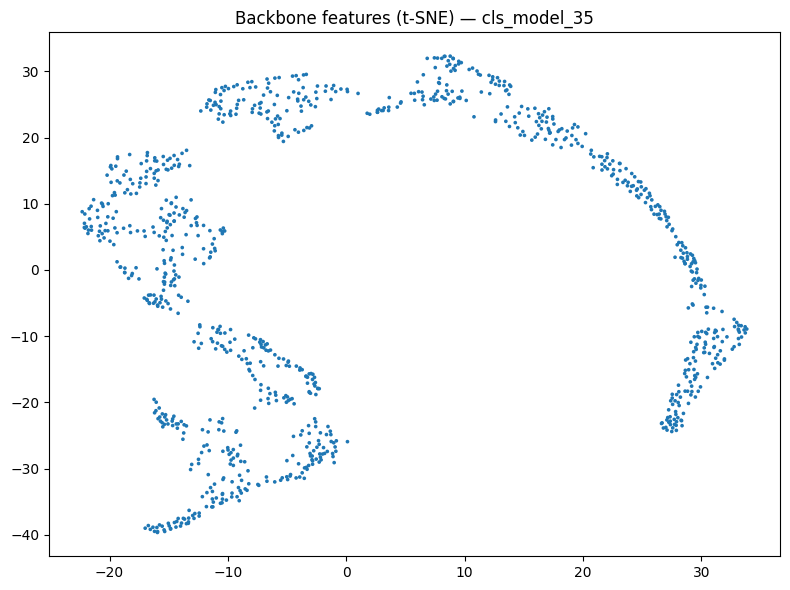

[cls_model_35] DBSCAN: clusters=2, noise=0 (eps=3.0, min_samples=10)
[plot] saved c:\Users\romai\OneDrive\Bureau\EPFL\MA3\Project\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE\extracted_features\cls_model_35_Default\cls_model_35_tsne_dbscan.png


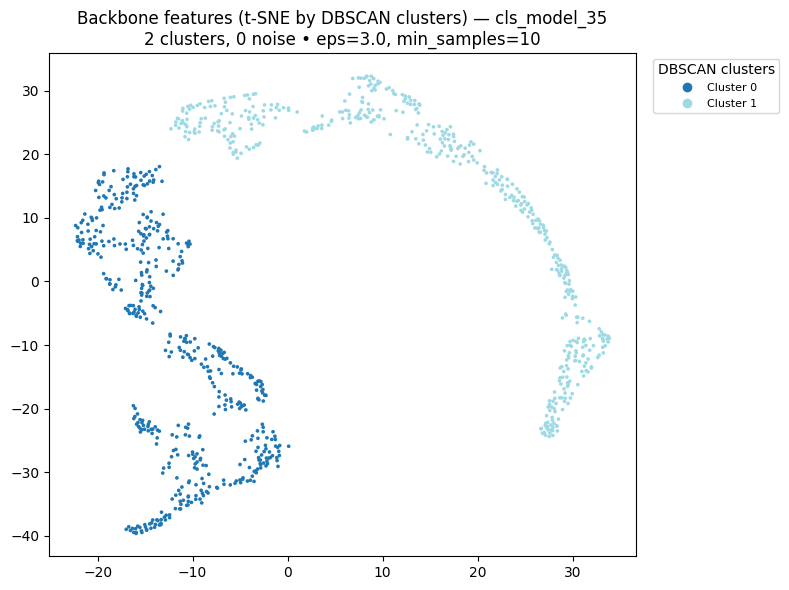

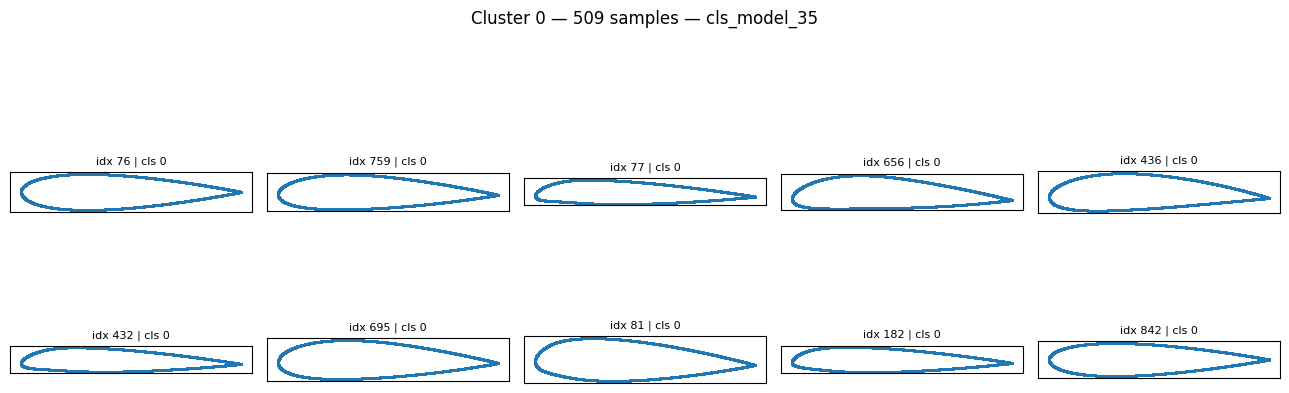

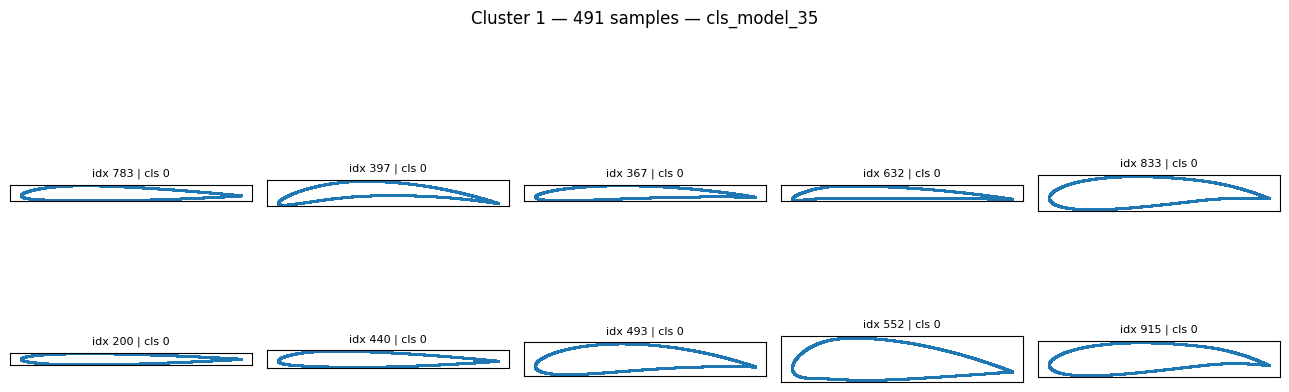

[plot] saved c:\Users\romai\OneDrive\Bureau\EPFL\MA3\Project\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE\extracted_features\cls_model_35_Default\cls_model_35_tsne_area.png


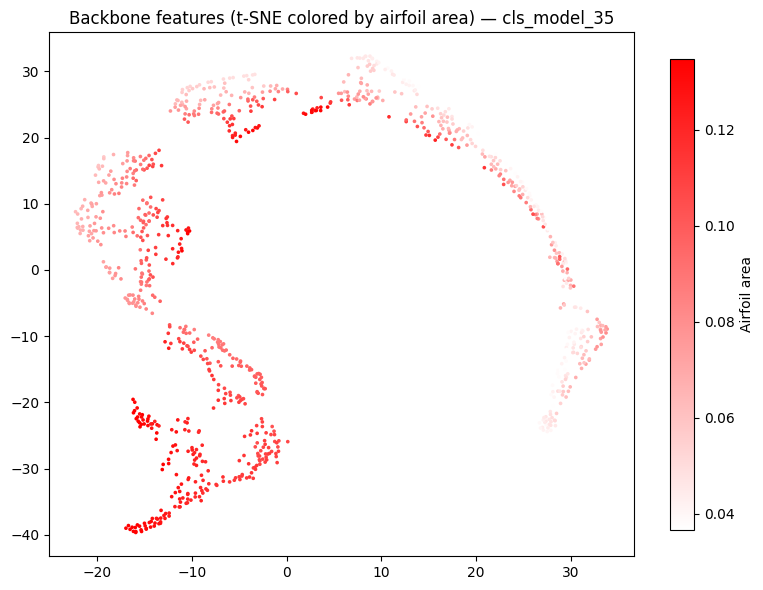

[cls_model_35] NACA kinds — 4-digit: 489, 5-digit: 511, unknown: 0
[plot] saved c:\Users\romai\OneDrive\Bureau\EPFL\MA3\Project\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE\extracted_features\cls_model_35_Default\cls_model_35_tsne_camber.png


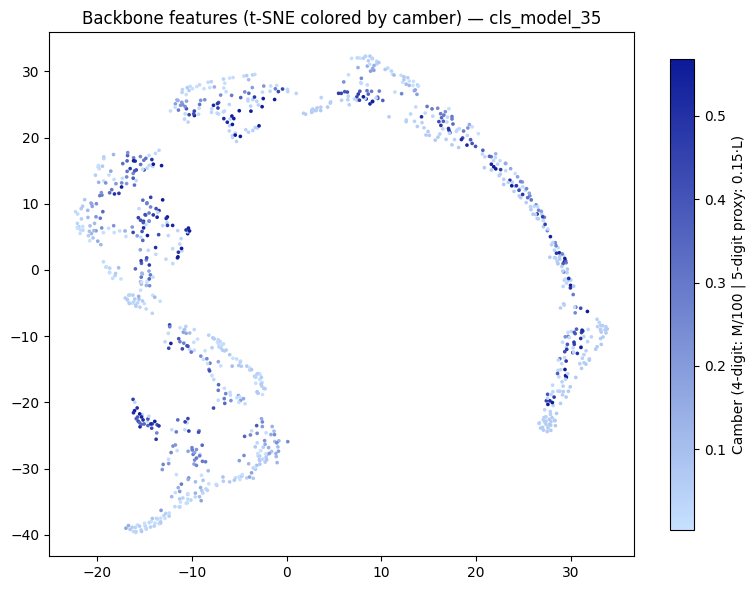

[plot] saved c:\Users\romai\OneDrive\Bureau\EPFL\MA3\Project\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE\extracted_features\cls_model_35_Default\cls_model_35_tsne_thickness.png


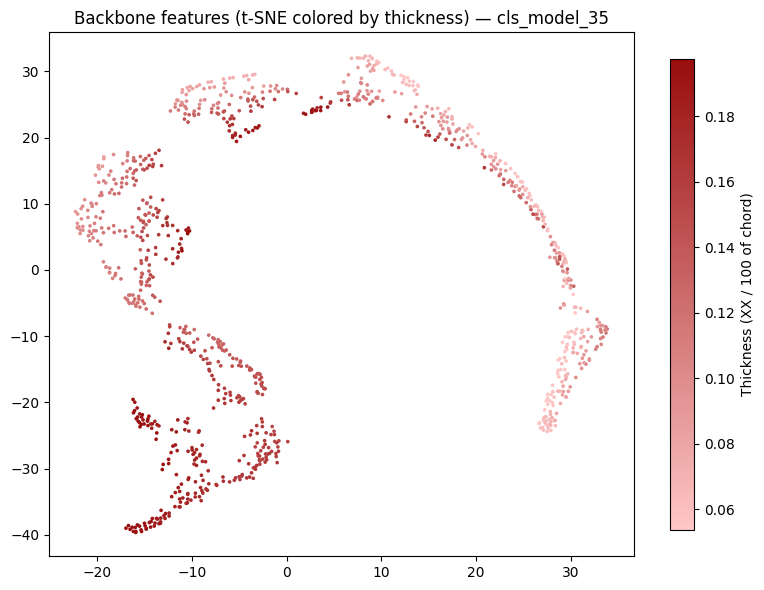

In [4]:
out35 = analyze_pointnet_backbone2('models/point_net/trained_models/cls_focal_clr/cls_model_35.pth', DEVICE, class_choice = ["Default"], plots = plots, data_folder = "shapenet_like_out2")

[cls_model_35] Model loaded from: models/point_net/trained_models/cls_focal_clr/cls_model_35.pth
[cls_model_35] Collected features: X=(1000, 1024), labels=(1000,)
[cls_model_35] Saved extracted features to:
  - c:\Users\romai\OneDrive\Bureau\EPFL\MA3\Project\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE\extracted_features\cls_model_35_normalized\cls_model_35_normalized_features.csv
  - c:\Users\romai\OneDrive\Bureau\EPFL\MA3\Project\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE\extracted_features\cls_model_35_normalized\cls_model_35_normalized_features.parquet
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1000 samples in 0.000s...
[t-SNE] Computed neighbors for 1000 samples in 0.016s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1000
[t-SNE] Mean sigma: 0.000139
[t-SNE] KL divergence after 250 iterations with early exaggeration: 54.163624
[t-SNE] KL divergence after 1000 iterations: 0.47

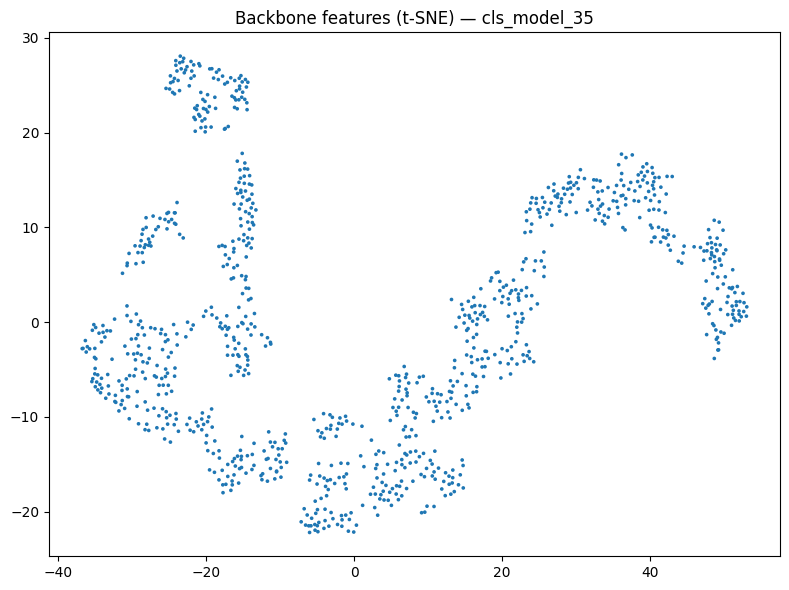

[cls_model_35] DBSCAN: clusters=5, noise=2 (eps=3.0, min_samples=10)
[plot] saved c:\Users\romai\OneDrive\Bureau\EPFL\MA3\Project\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE\extracted_features\cls_model_35_normalized\cls_model_35_tsne_dbscan.png


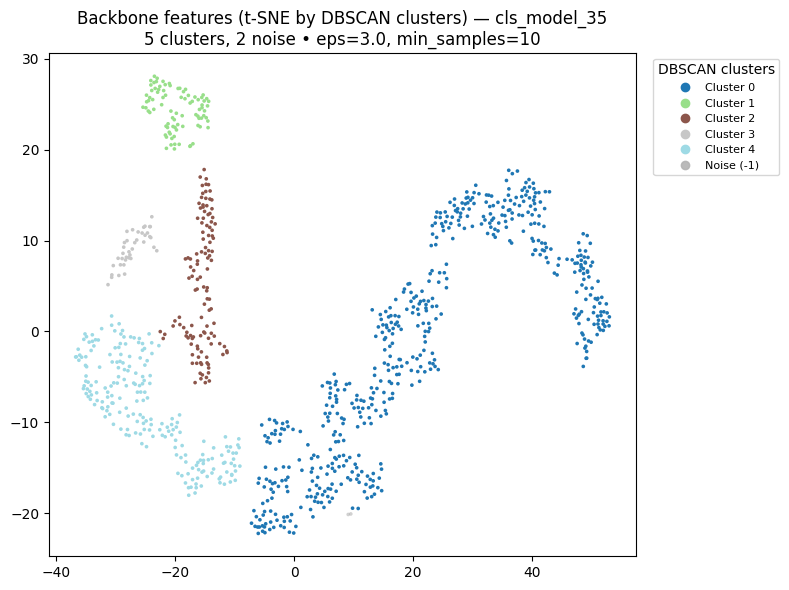

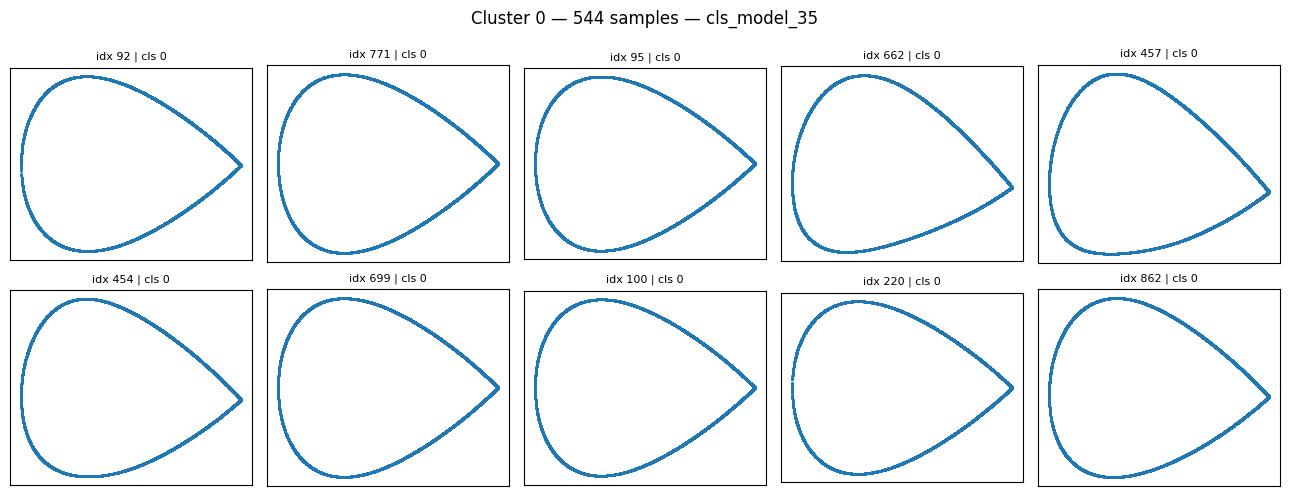

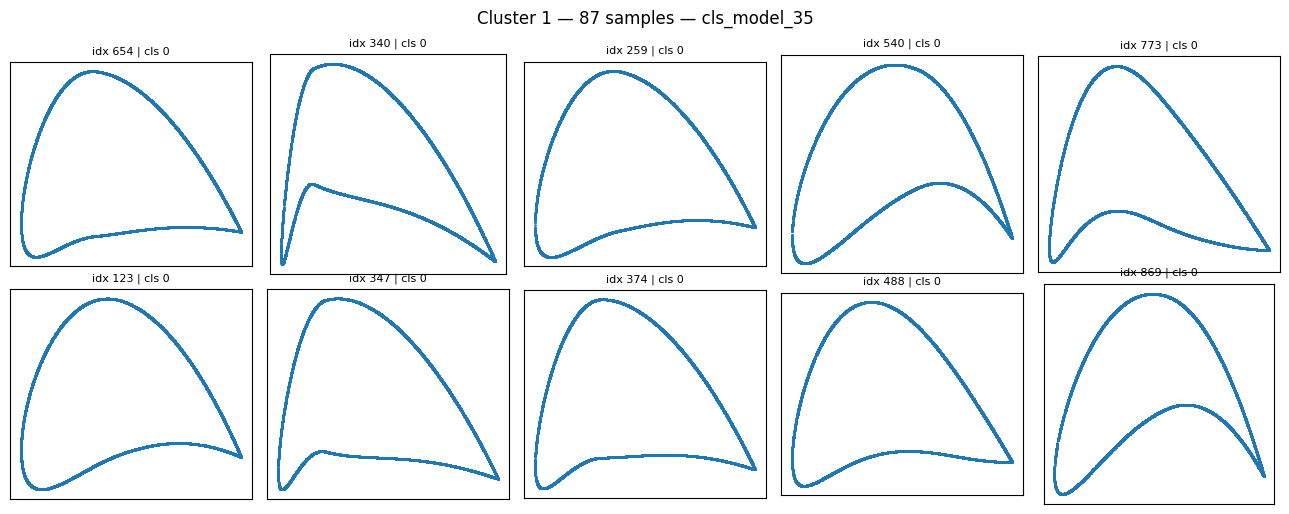

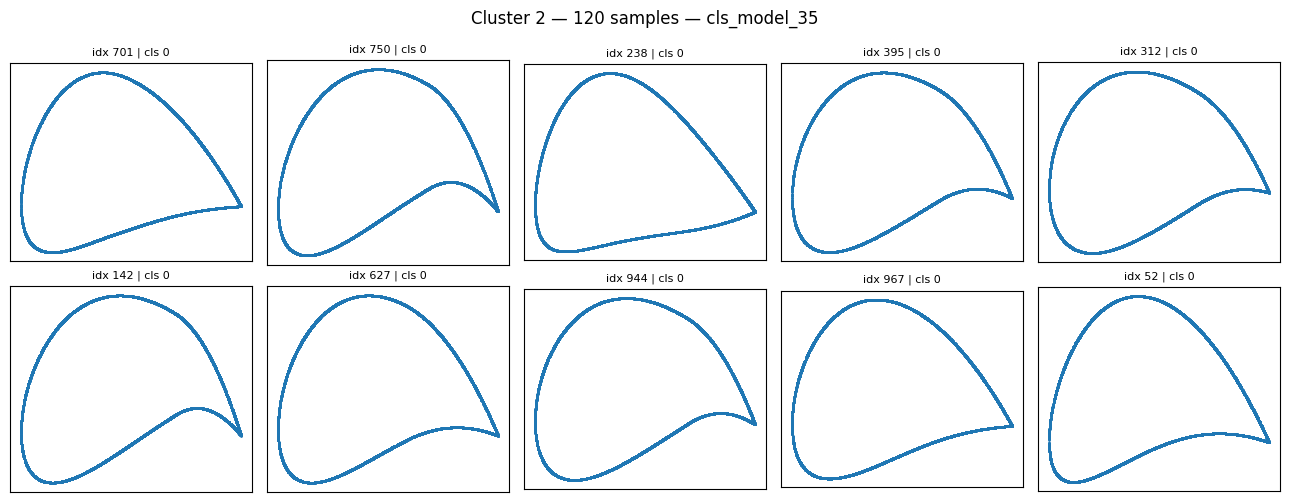

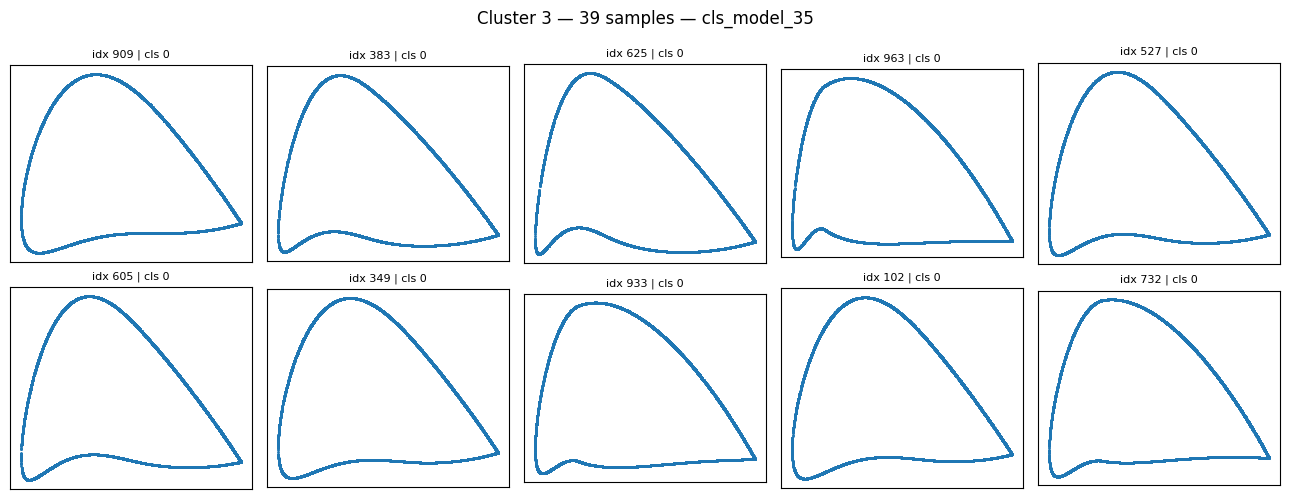

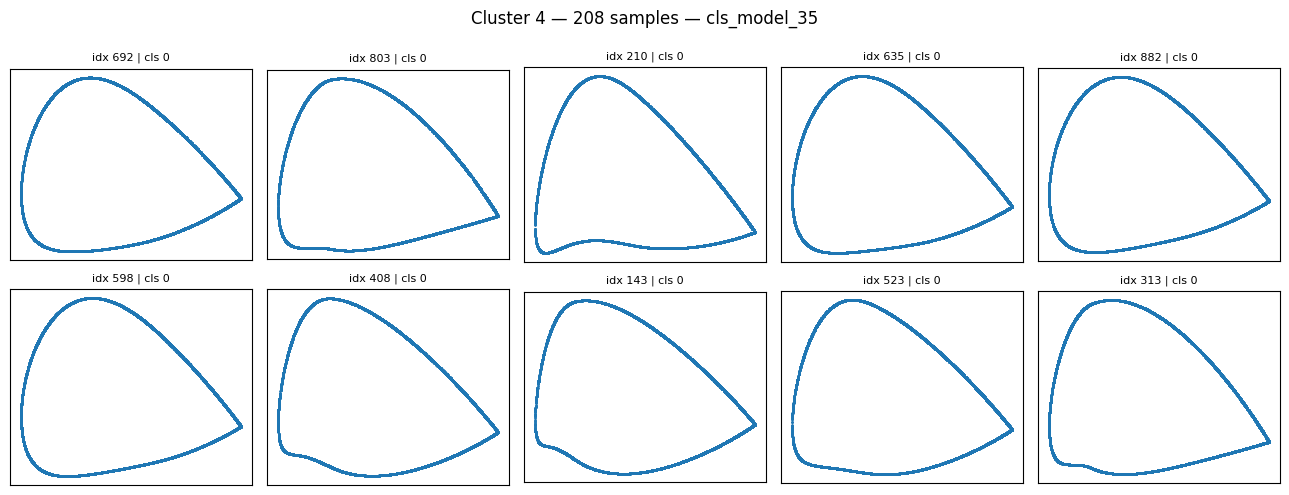

[plot] saved c:\Users\romai\OneDrive\Bureau\EPFL\MA3\Project\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE\extracted_features\cls_model_35_normalized\cls_model_35_tsne_area.png


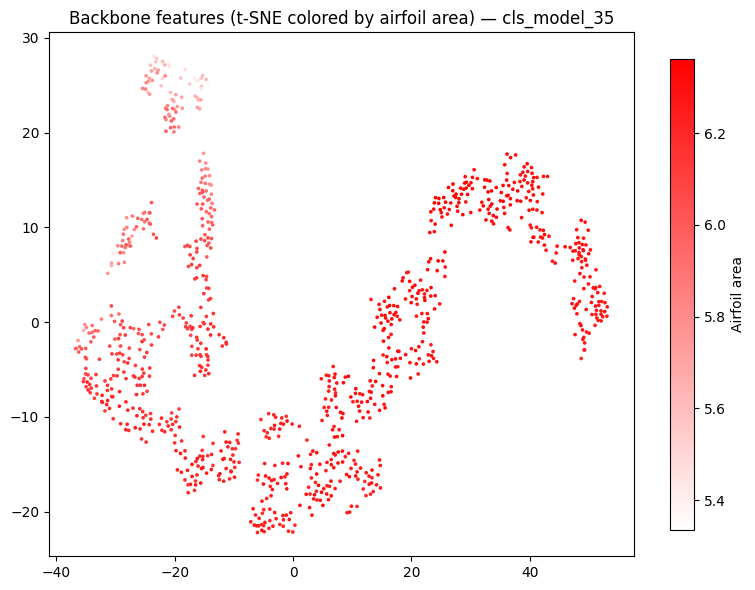

[cls_model_35] NACA kinds — 4-digit: 489, 5-digit: 511, unknown: 0
[plot] saved c:\Users\romai\OneDrive\Bureau\EPFL\MA3\Project\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE\extracted_features\cls_model_35_normalized\cls_model_35_tsne_camber.png


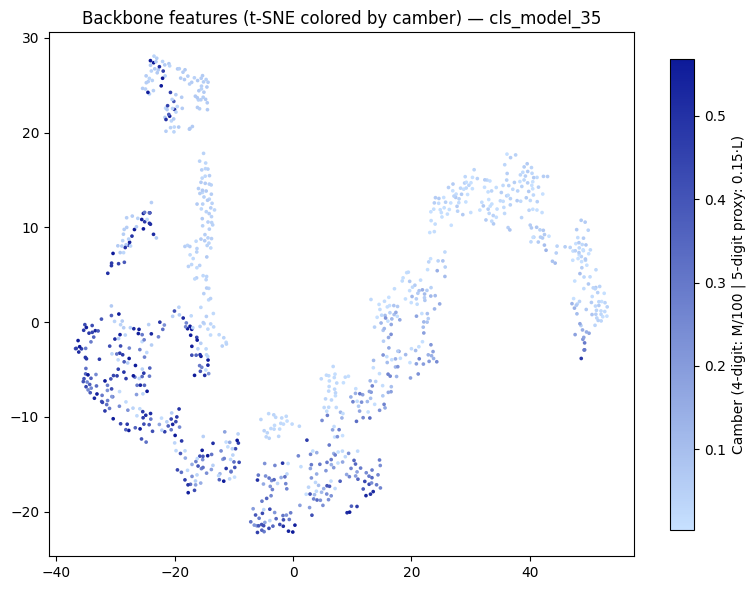

[plot] saved c:\Users\romai\OneDrive\Bureau\EPFL\MA3\Project\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE\extracted_features\cls_model_35_normalized\cls_model_35_tsne_thickness.png


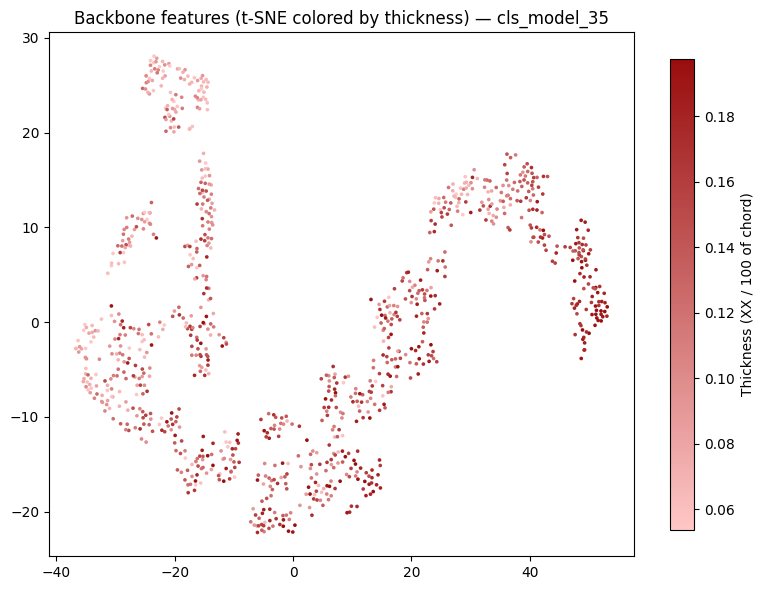

In [5]:
out35 = analyze_pointnet_backbone2('models/point_net/trained_models/cls_focal_clr/cls_model_35.pth', DEVICE, class_choice = ["normalized"],plots = plots, data_folder = "shapenet_like_out2")